# Exploratory Data Analysis

**Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

**Source:** Combination of 5 heart disease datasets (Cleveland, Hungarian, Switzerland, Long Beach VA, Stalog)

---

### Table of Contents

1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Data Quality Assessment](#3)
4. [Target Variable Distribution](#4)
5. [Univariate Analysis](#5)
6. [Bivariate Analysis: Features vs Target](#6)
7. [Correlation Analysis](#7)
9. [Summary & Key Findings](#8)

<a id='1'></a>
## 1. Setup & Data Loading

Import required libraries and configure the global plotting style for consistent, publication-quality figures.

In [41]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Global settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

# Plotting style
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
PALETTE_TARGET = {"No Disease": "#3A86FF", "Disease": "#FF006E"}
FIG_DPI = 120
plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.titlesize": 16,
    "figure.titleweight": "bold",
})

In [42]:
# Load dataset
DATA_PATH = "data/raw/initial_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 918 rows × 12 columns


<a id='2'></a>
## 2. Dataset Overview

The dataset consists of **11 clinical features** and **1 binary target** (`HeartDisease`).

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | `Age` | Numerical | Age of the patient (years) |
| 2 | `Sex` | Categorical | M: Male, F: Female |
| 3 | `ChestPainType` | Categorical | TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic |
| 4 | `RestingBP` | Numerical | Resting blood pressure (mm Hg) |
| 5 | `Cholesterol` | Numerical | Serum cholesterol (mm/dl) |
| 6 | `FastingBS` | Binary | 1 if fasting blood sugar > 120 mg/dl, 0 otherwise |
| 7 | `RestingECG` | Categorical | Normal, ST: ST-T wave abnormality, LVH: left ventricular hypertrophy |
| 8 | `MaxHR` | Numerical | Maximum heart rate achieved (60–202) |
| 9 | `ExerciseAngina` | Categorical | Y: Yes, N: No |
| 10 | `Oldpeak` | Numerical | ST depression (numeric) |
| 11 | `ST_Slope` | Categorical | Up: upsloping, Flat: flat, Down: downsloping |
| **Target** | `HeartDisease` | Binary | 1: heart disease, 0: normal |

In [43]:
# Firts 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [44]:
# FastingBS is binary but stored as numeric, convert to categorical for clarity
df['FastingBS'] = df['FastingBS'].astype(str)

# Separate feature types
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove("HeartDisease")

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features  ({len(numerical_cols)}): {numerical_cols}")

Categorical features (6): ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical features  (5): ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


In [45]:
# Numerical summary
df[numerical_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.51,9.43,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.40,18.51,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.80,109.38,0.0,173.25,223.0,267.0,603.0
MaxHR,918.0,136.81,25.46,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.89,1.07,-2.6,0.00,0.6,1.5,6.2


In [46]:
# Categorical summary
df[categorical_cols].describe().T

,count,unique,top,freq
Sex,918,2,M,725
ChestPainType,918,4,ASY,496
FastingBS,918,2,0,704
RestingECG,918,3,Normal,552
ExerciseAngina,918,2,N,547
ST_Slope,918,3,Flat,460


<a id='3'></a>
## 3. Data Quality Assessment

This section checks for missing values, duplicated rows, and anomalous zero-values that may indicate encoding errors in the original source datasets.

In [47]:
# Missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values detected.")
else:
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
    missing_report = missing_report[missing_report["Missing"] > 0]
    display(missing_report)

No missing values detected.


In [48]:
# Duplicate rows
n_dupes = df.duplicated().sum()
if n_dupes == 0:
    print("No duplicate rows detected.")
else:
    print(f"Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.1f}%)")

No duplicate rows detected.


In [49]:
# Zero values in numerical features
# FastingBS and Oldpeak are not included as 0 can be valid values (e.g. no fasting, no ST depression)
zero_check_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR"]
zero_report = []
for col in zero_check_cols:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    zero_report.append({"Feature": col, "Zero Count": n_zeros, "% of Total": round(pct, 1)})

zero_df = pd.DataFrame(zero_report).set_index("Feature")
display(zero_df)

,Zero Count,% of Total
Feature,,
Age,0,0.0
RestingBP,1,0.1
Cholesterol,172,18.7
MaxHR,0,0.0


As highlighted by the table above, there are some values that are clinically impossible:

- *RestingBP* (Resting Blood Pressure): There is 1 record with a value of 0. A blood pressure of zero is biologically impossible for a living patient.

- *Cholesterol* (Serum Cholesterol): There are 172 records (nearly 19% of the dataset) with a value of 0. While very low cholesterol exists, an absolute 0 mg/dl is clinically invalid.

These zero values are clearly masked missing values entered during the data collection process.

**Action taken:** These zeros are replaced with `NaN` so that all subsequent analyses (distributions, correlations) automatically exclude them. This avoids artificially deflating means and inflating variances. Proper imputation, if needed, will be handled in the preprocessing phase.

In [50]:
# Replace clinically impossible zeros with NaN
# No imputation here (that belongs to the preprocessing step).
# Converting to NaN ensures all downstream statistics ignore these entries.
cols_to_fix = ["Cholesterol", "RestingBP"]
for col in cols_to_fix:
    n_before = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    print(f"  {col}: {n_before} zeros -> NaN")

print(f"\nDataset shape unchanged: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Effective non-null counts: Cholesterol = {df['Cholesterol'].notna().sum()}, RestingBP = {df['RestingBP'].notna().sum()}")

  Cholesterol: 172 zeros -> NaN
  RestingBP: 1 zeros -> NaN

Dataset shape unchanged: 918 rows x 12 columns
Effective non-null counts: Cholesterol = 746, RestingBP = 917


<a id='4'></a>
## 4. Target Variable Distribution

Before exploring features, the balance of the target variable `HeartDisease` is examined.

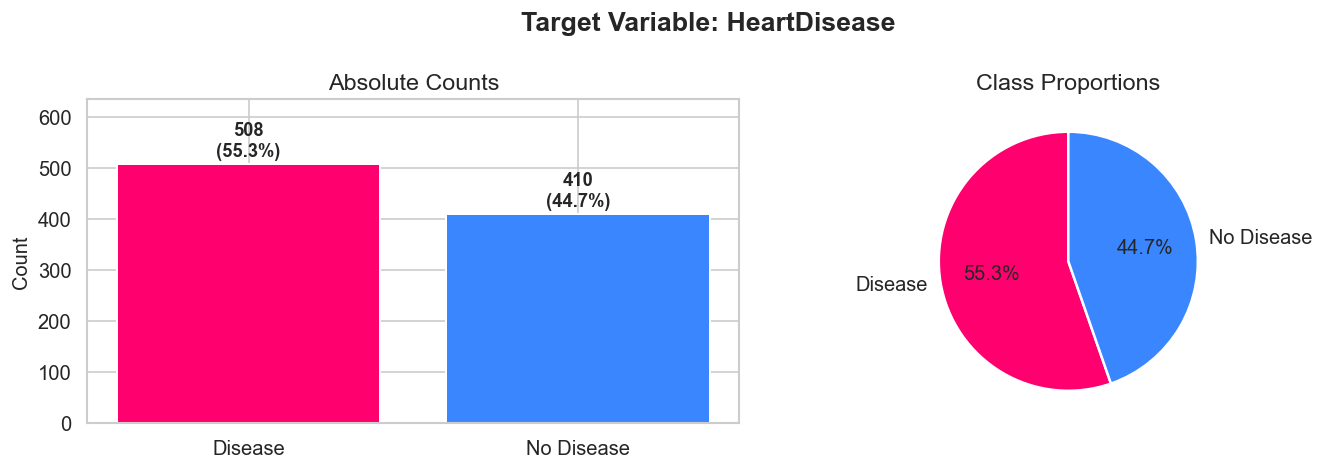

Imbalance ratio: 1.24:1
The dataset is reasonably balanced


In [51]:
# Target distribution
target_counts = df["HeartDisease"].value_counts().rename({0: "No Disease", 1: "Disease"})
target_pct = (target_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Map each label to its correct colour
bar_colors = [PALETTE_TARGET[label] for label in target_counts.index]

# Count plot
bars = axes[0].bar(target_counts.index, target_counts.values,
                   color=bar_colors,
                   edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                 f"{int(bar.get_height())}\n({pct}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_title("Absolute Counts")
axes[0].set_ylim(0, target_counts.max() * 1.25)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            colors=bar_colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12},
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Class Proportions")

fig.suptitle("Target Variable: HeartDisease")
plt.tight_layout()
plt.show()

ratio = target_counts.max() / target_counts.min()
print(f"Imbalance ratio: {ratio:.2f}:1")
if ratio < 1.5:
    print("The dataset is reasonably balanced")
else:
    print("Imbalance detected")

<a id='5'></a>
## 5. Univariate Analysis

This section explores the distribution of each categorical variable independently before examining its relationship with the target.

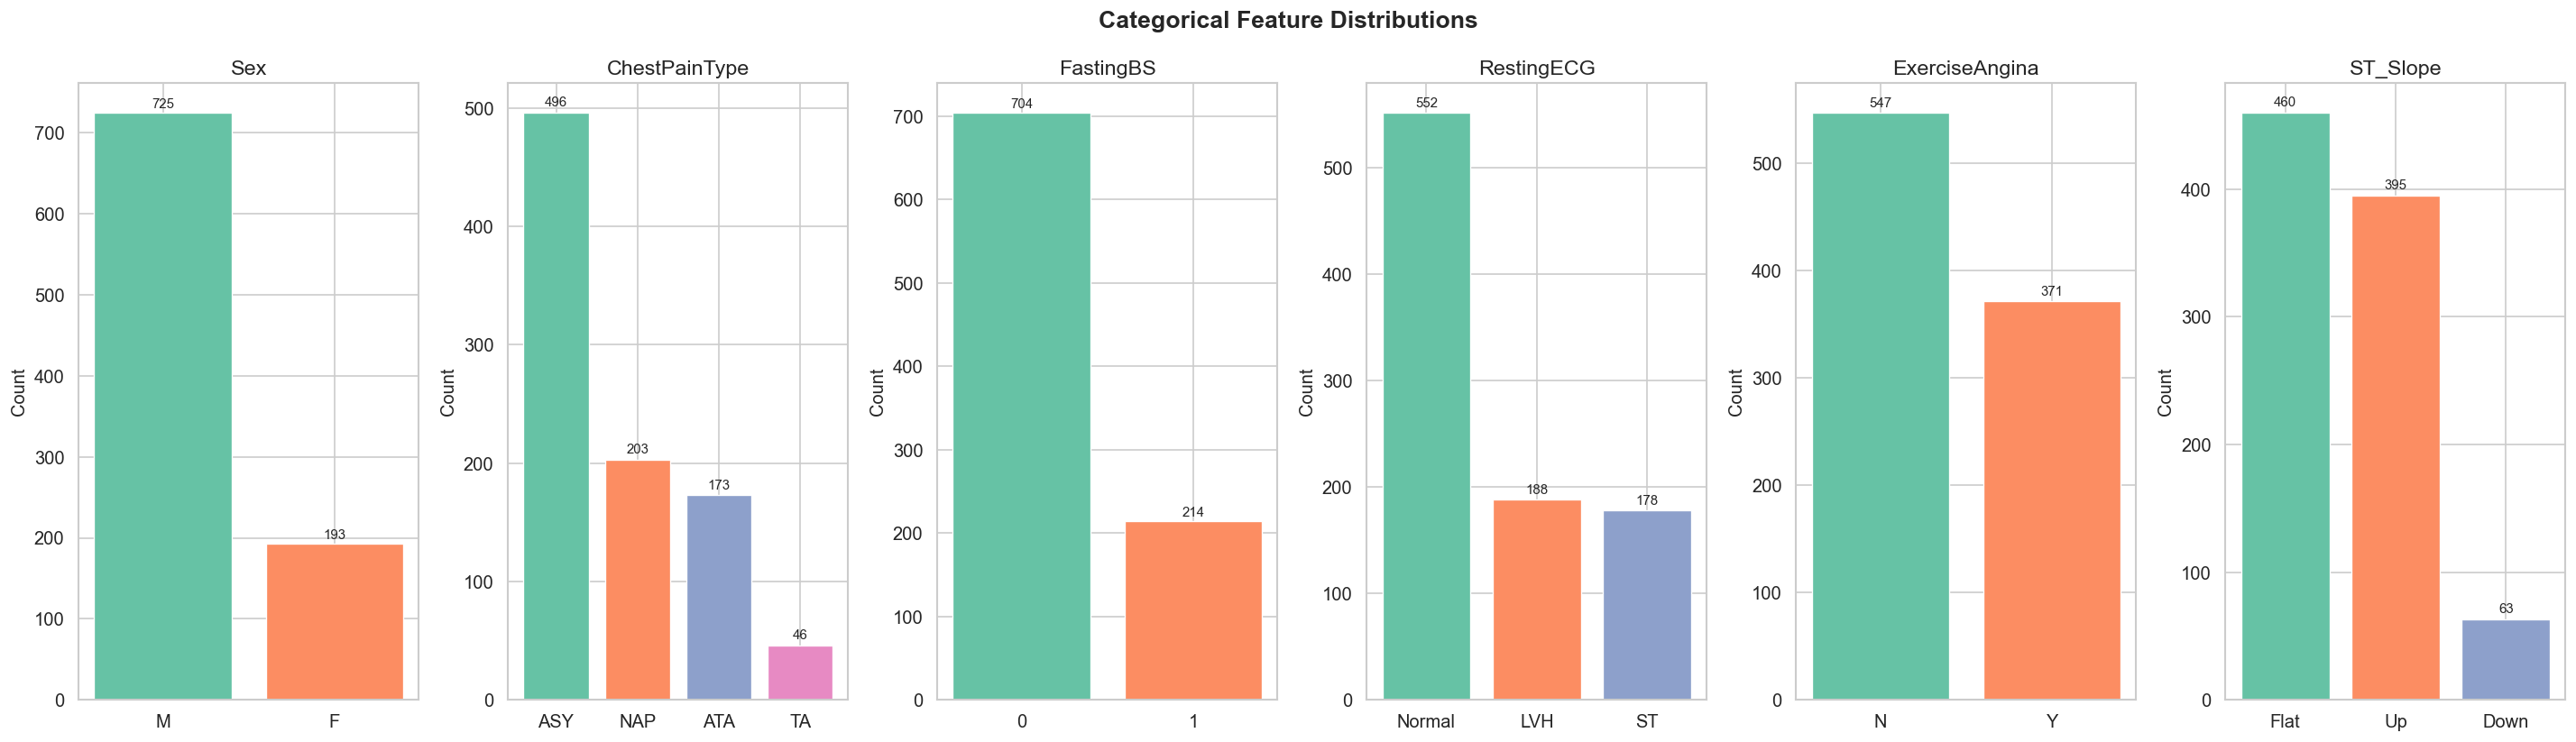

In [52]:
# Categorical feature distributions
n_cat = len(categorical_cols)
fig, axes = plt.subplots(1, n_cat, figsize=(4 * n_cat, 7), sharey=False)

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette("Set2", n_colors=len(counts)),
                  edgecolor="white", linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 3,
                f"{int(h)}", ha="center", va="bottom", fontsize=9)
    ax.set_title(col)
    ax.set_ylabel("Count")

fig.suptitle("Categorical Feature Distributions")
plt.tight_layout()
plt.show()

Histograms with overlaid KDE curves reveal the shape of each numerical distribution, helping identify skewness and potential outliers.

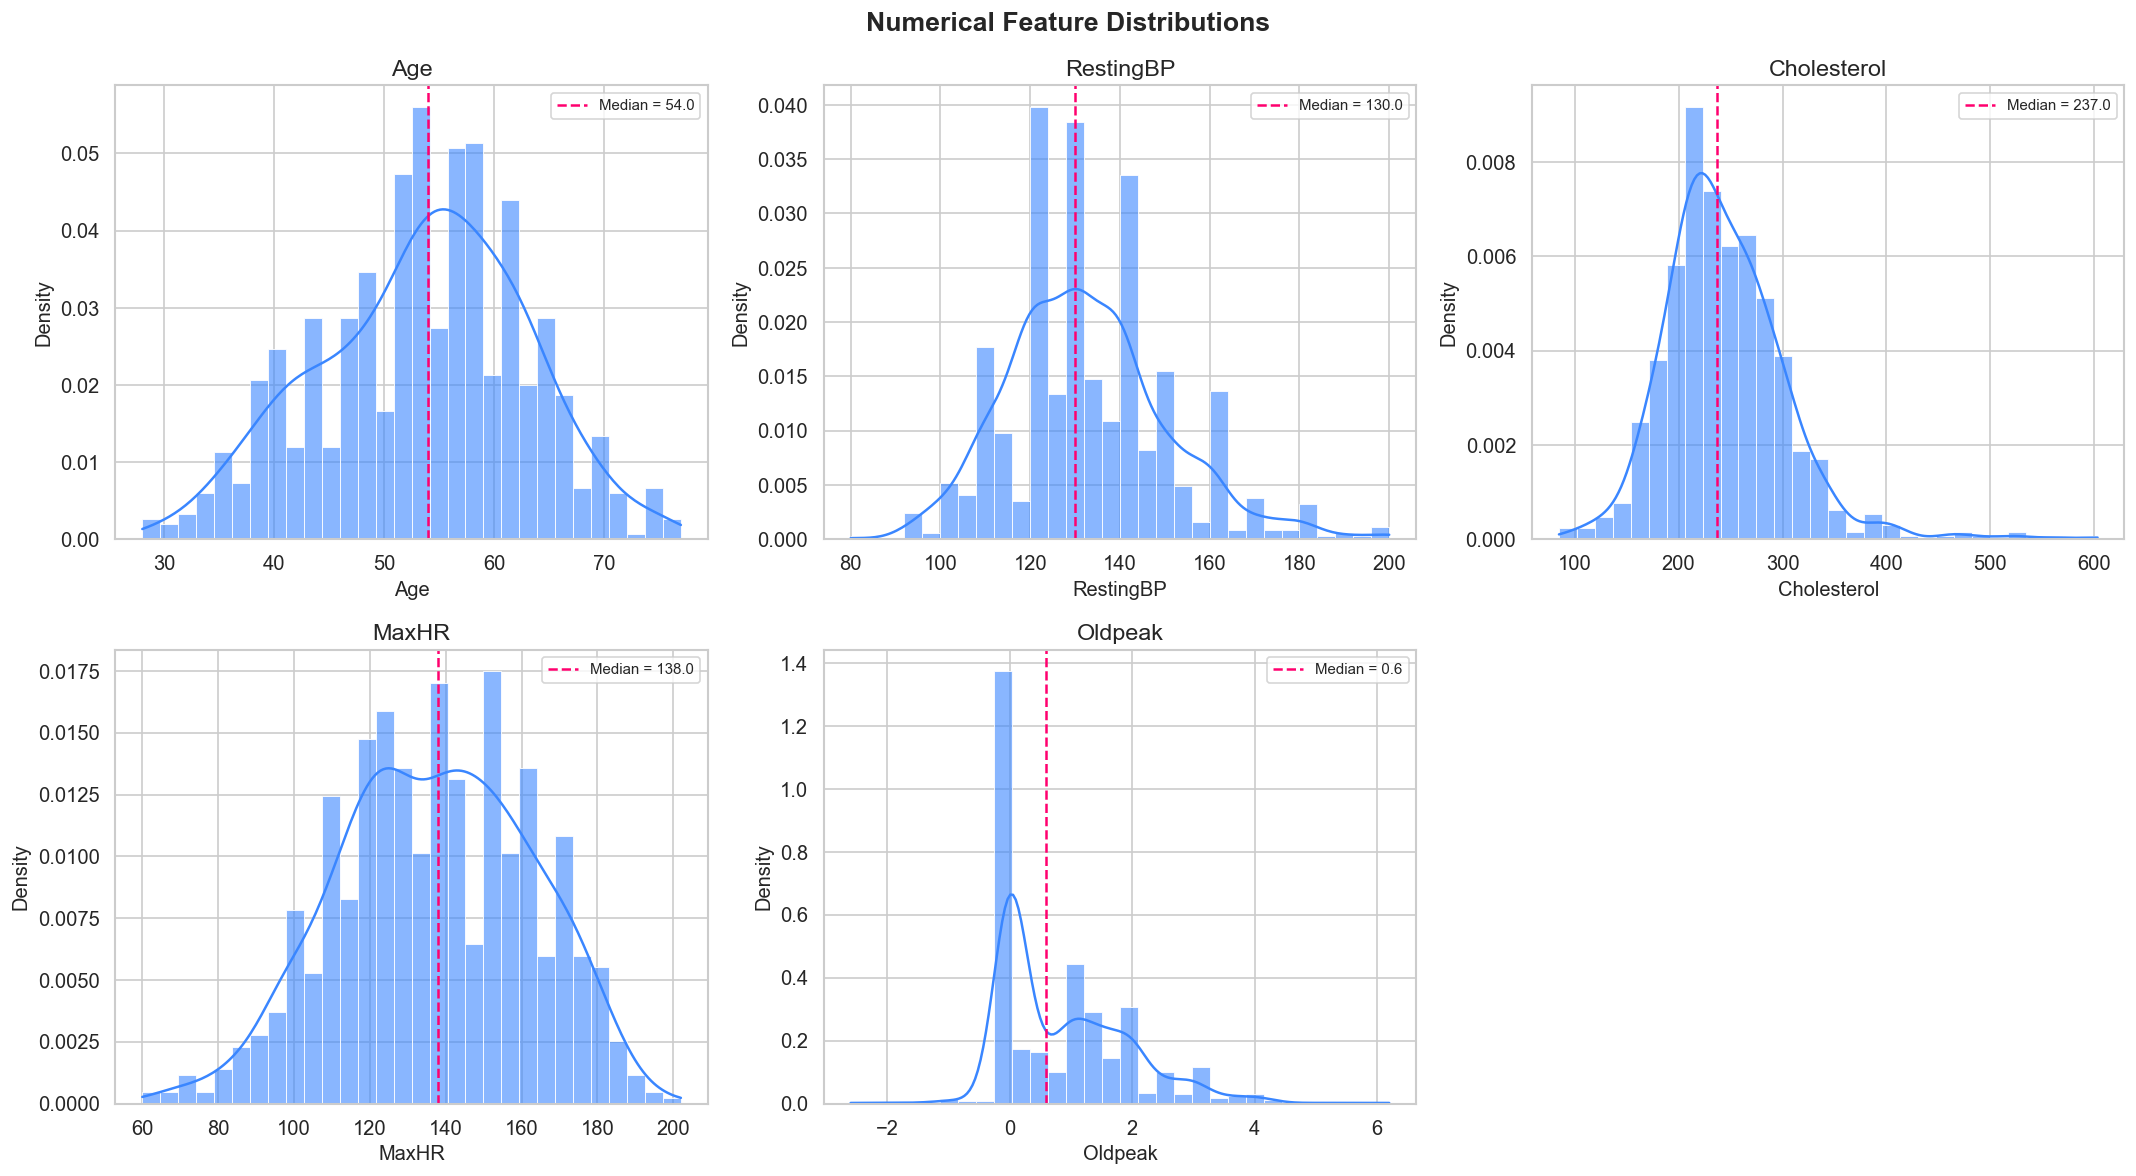

In [53]:
# Numerical feature distributions
n_num = len(numerical_cols)
n_rows = (n_num + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    sns.histplot(df[col], kde=True, ax=ax, color="#3A86FF", edgecolor="white",
                 stat="density", bins=30, alpha=0.6, linewidth=0.5)
    ax.axvline(df[col].median(), color="#FF006E", linestyle="--", linewidth=1.5, label=f"Median = {df[col].median():.1f}")
    ax.set_title(col)
    ax.legend(fontsize=9)

# Hide unused subplots
for idx in range(n_num, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

### Observations: Univariate Analysis

**Categorical features:**

| Feature | Distribution |
|---------|-------------|
| **Sex** | Heavily imbalanced towards males (~725 M vs ~193 F), reflecting clinical recruitment bias. |
| **ChestPainType** | Dominated by asymptomatic (ASY) patients, followed by non-anginal pain (NAP). |
| **RestingECG** | Mostly normal, with smaller ST and LVH groups. |
| **ExerciseAngina** | Splits roughly 50/50 between Y and N. |
| **ST_Slope** | Predominantly Flat and Up, with very few Down cases. |
| **FastingBS** | Predominantly 0 (normal), with ~76% of patients (704 vs 214) showing fasting blood sugar below 120 mg/dl. |


**Numerical features:**

| Feature | Distribution |
|---------|-------------|
| **Age** | Roughly normal, centred around 53–55 years. |
| **RestingBP** | Approximately normal (median ≈ 130 mm Hg), with mild right skewness. |
| **Cholesterol** | After zero removal, unimodal around 230–240 mg/dl with a right tail of high values. |
| **MaxHR** | Broad distribution spanning ~60–200, with a slight left skew. |
| **Oldpeak** | Heavily right-skewed: most values clustered near 0 with a long tail towards 6. |

<a id='6'></a>
## 6. Bivariate Analysis: Features vs. Target

For each categorical feature, two complementary views are computed:

| View | Formula | Question answered |
|------|---------|-------------------|
| **Risk (left)** | $P(\text{Disease} \mid \text{Category})$ | *"Given this category, what is the probability of disease?"* |
| **Profile (right)** | $P(\text{Category} \mid \text{Disease})$ | *"Among diseased patients, how are categories distributed?"* |

In [54]:
# Helper: annotate bars
def annotate_bars(ax, fmt="{:.1%}", pad=4, fontsize=10, color="black"):
    """Add formatted labels on top of each bar."""
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h):
            continue
        ax.annotate(fmt.format(h),
                    xy=(p.get_x() + p.get_width() / 2, h),
                    xytext=(0, pad), textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize, color=color)

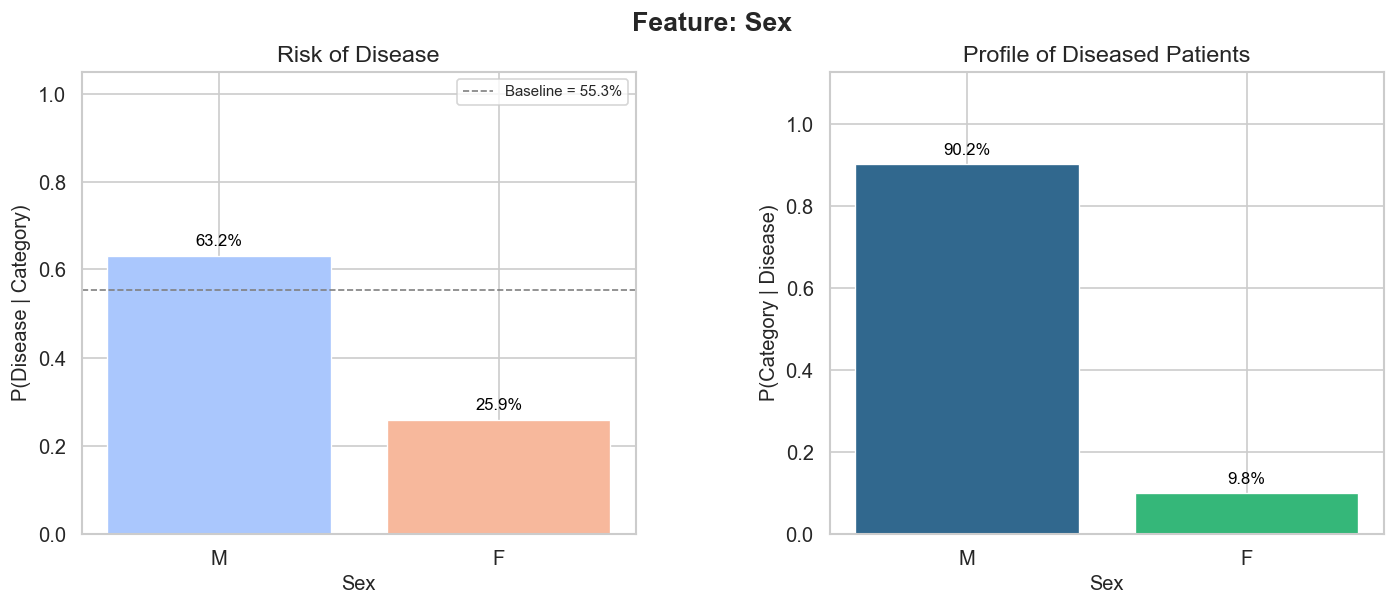

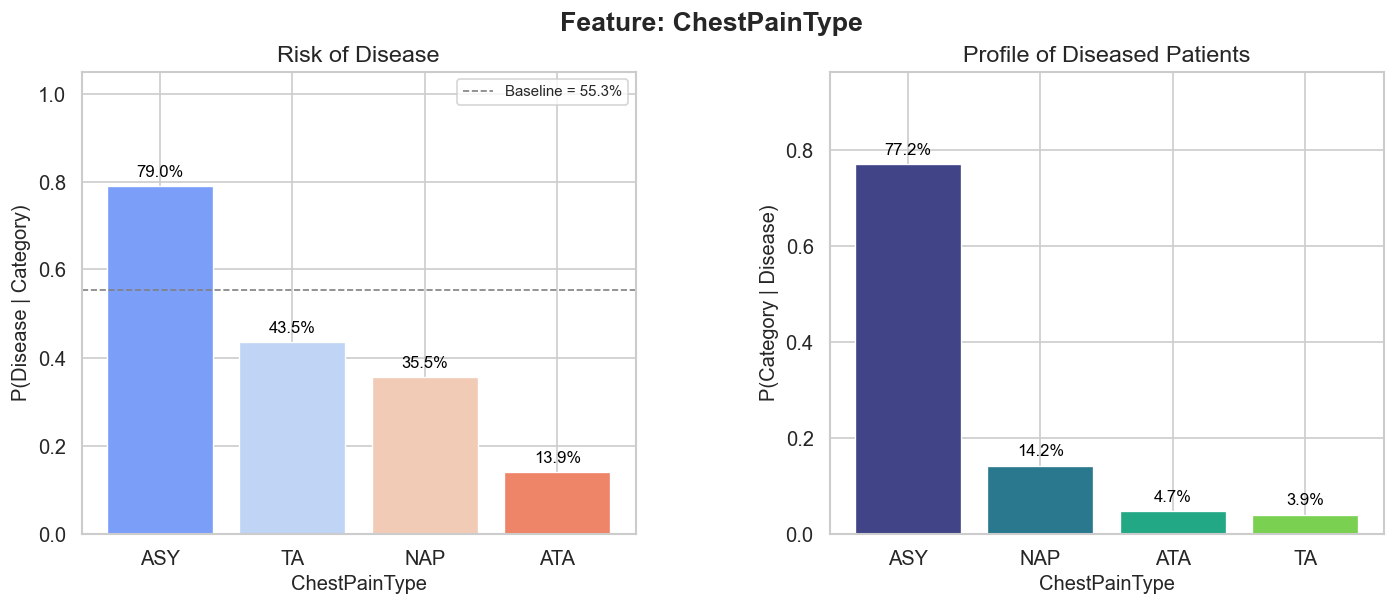

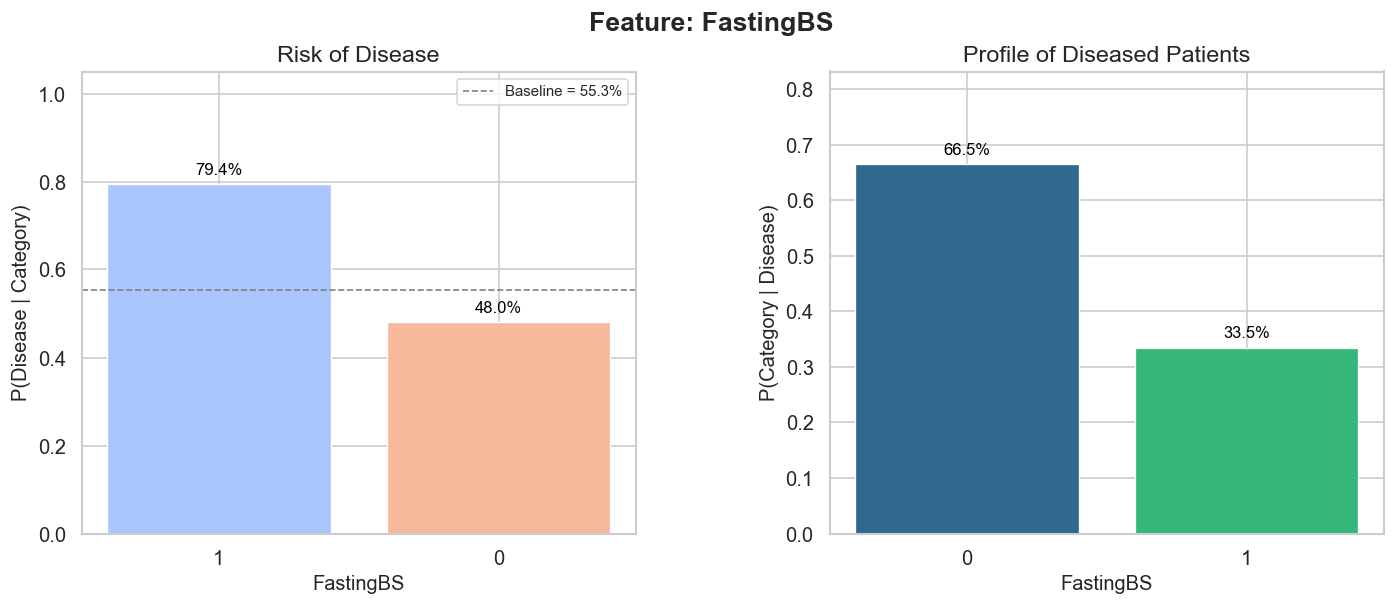

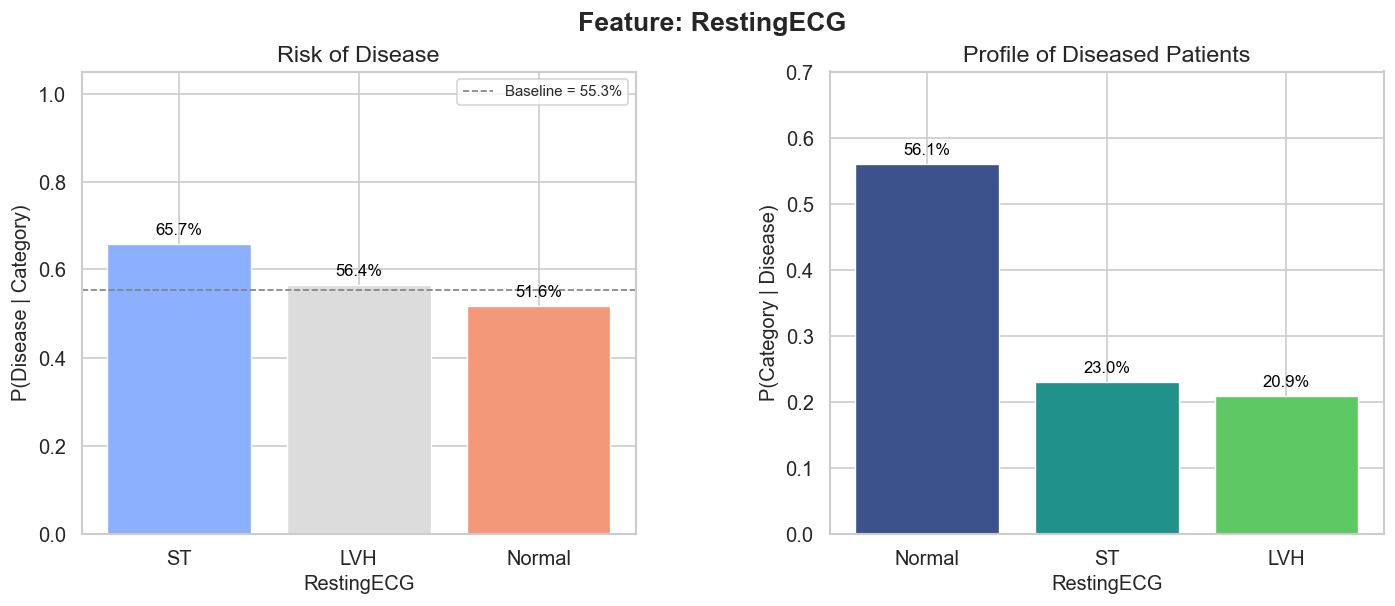

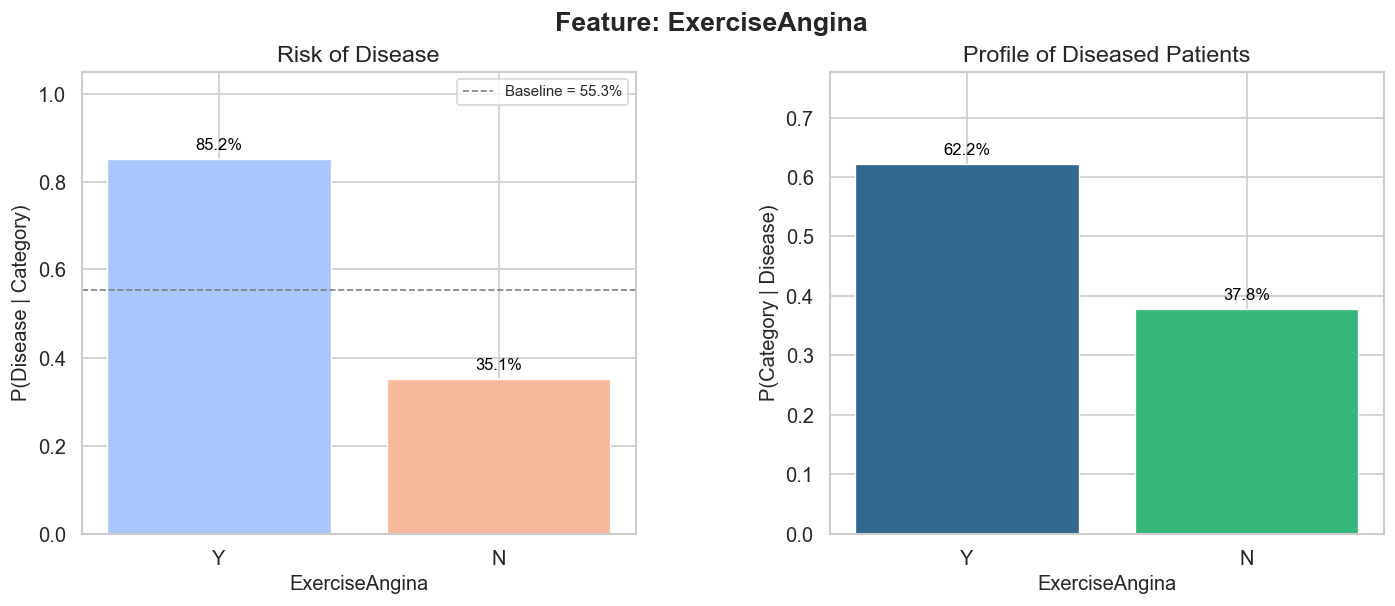

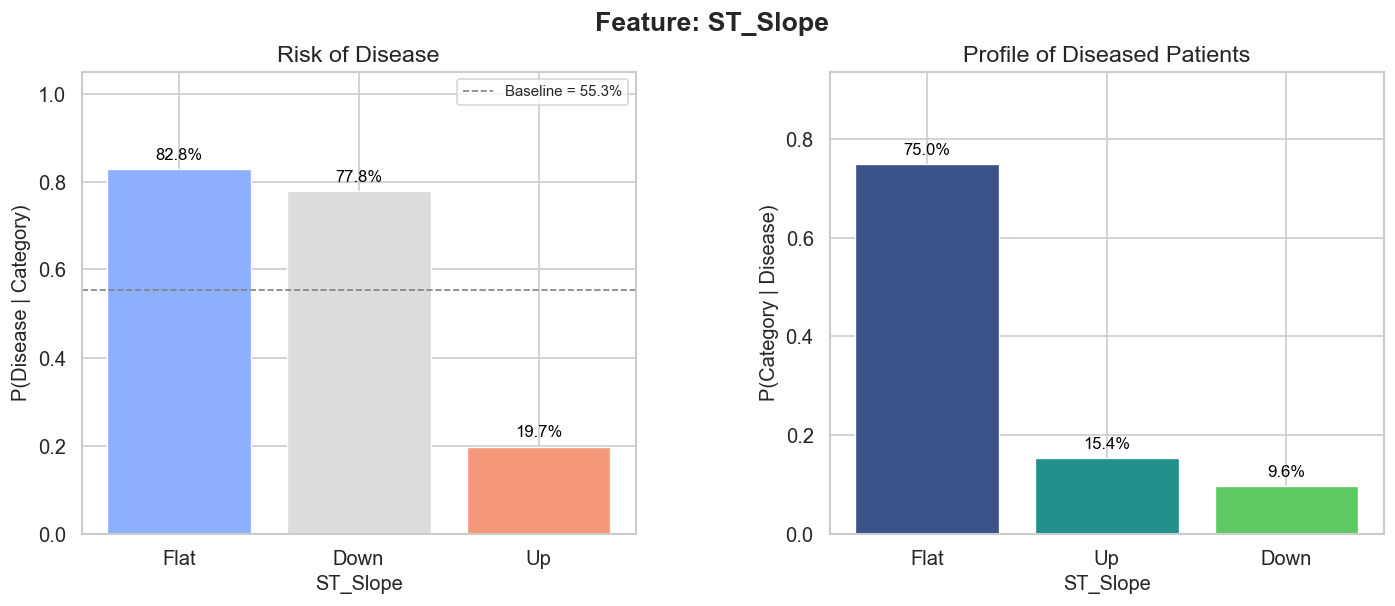

In [55]:
# Categorical features vs. HeartDisease
for col in categorical_cols:
    risk = df.groupby(col)["HeartDisease"].mean().sort_values(ascending=False)
    profile = (
        df.groupby("HeartDisease")[col]
          .value_counts(normalize=True)
          .loc[1]
          .sort_values(ascending=False)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"wspace": 0.35})

    # Risk plot
    colors_risk = sns.color_palette("coolwarm", n_colors=len(risk))
    ax1.bar(risk.index, risk.values, color=colors_risk, edgecolor="white", linewidth=0.8)
    ax1.set_ylabel("P(Disease | Category)")
    ax1.set_xlabel(col)
    ax1.set_title("Risk of Disease")
    ax1.set_ylim(0, 1.05)
    ax1.axhline(df["HeartDisease"].mean(), color="grey", linestyle="--",
                linewidth=1, label=f"Baseline = {df['HeartDisease'].mean():.1%}")
    ax1.legend(fontsize=9)
    annotate_bars(ax1)

    # Profile plot
    colors_prof = sns.color_palette("viridis", n_colors=len(profile))
    ax2.bar(profile.index, profile.values, color=colors_prof, edgecolor="white", linewidth=0.8)
    ax2.set_ylabel("P(Category | Disease)")
    ax2.set_xlabel(col)
    ax2.set_title("Profile of Diseased Patients")
    ax2.set_ylim(0, max(profile.values) * 1.25)
    annotate_bars(ax2)

    fig.suptitle(f"Feature: {col}")
    plt.tight_layout()
    plt.show()

### Observations: Categorical Features

| Feature | Key Finding |
|---------|-------------|
| **Sex** | Males (63.2%) have a significantly higher risk than Females (25.9%). The diseased population is overwhelmingly male (90.2%). |
| **ChestPainType** | Asymptomatic (ASY) pain carries the highest risk (79.0%); Atypical Angina (ATA) is the safest (13.9%). 77.2% of diseased patients present with ASY. |
| **RestingECG** | All categories show similar risk (52–66%). This appears to be a weak predictor. Notably, 56.1% of diseased patients had a normal ECG. |
| **ExerciseAngina** | Exercise-induced angina (Y) is a very strong predictor: 85.2% risk. 62.2% of diseased patients are positive. |
| **ST_Slope** | 'Flat' (82.8%) and 'Down' (77.8%) are extremely high-risk. An 'Up' slope indicates health (only 19.7% risk). |
| **FastingBS** | Elevated blood sugar is a strong risk factor (~80% risk). Normal levels present a 50/50 chance (~48% risk) and do not rule out the disease. |

The following plots compare distributions (KDE) and medians/spreads (box plots, violin plots) between the two outcome groups.

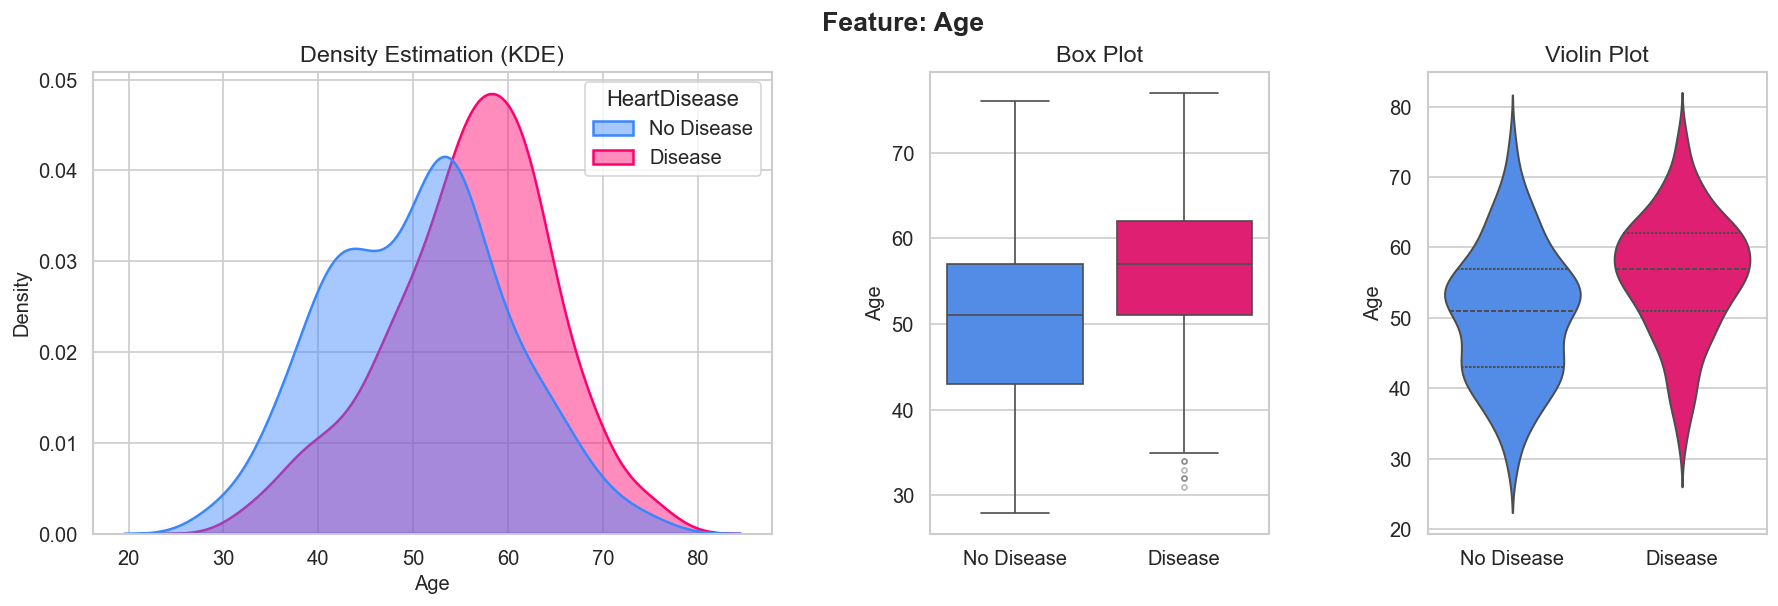

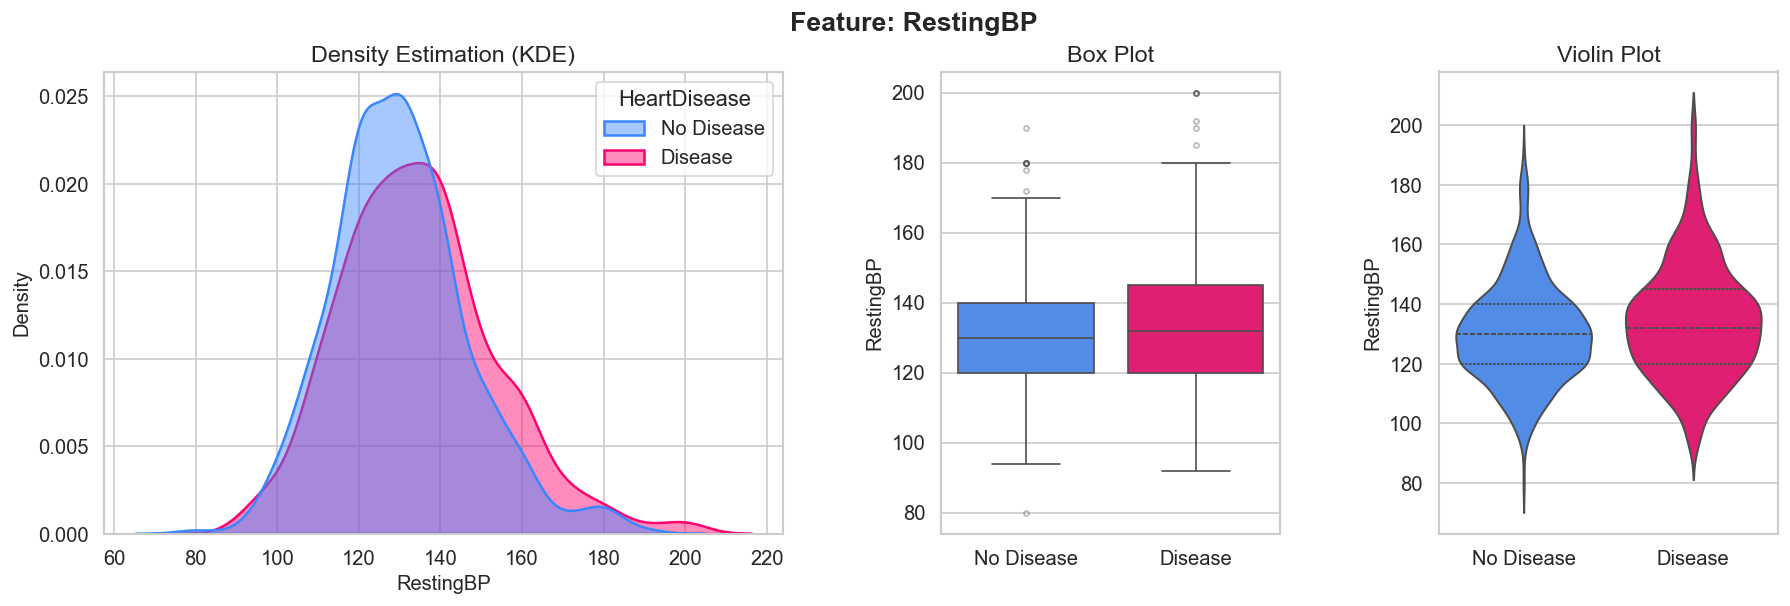

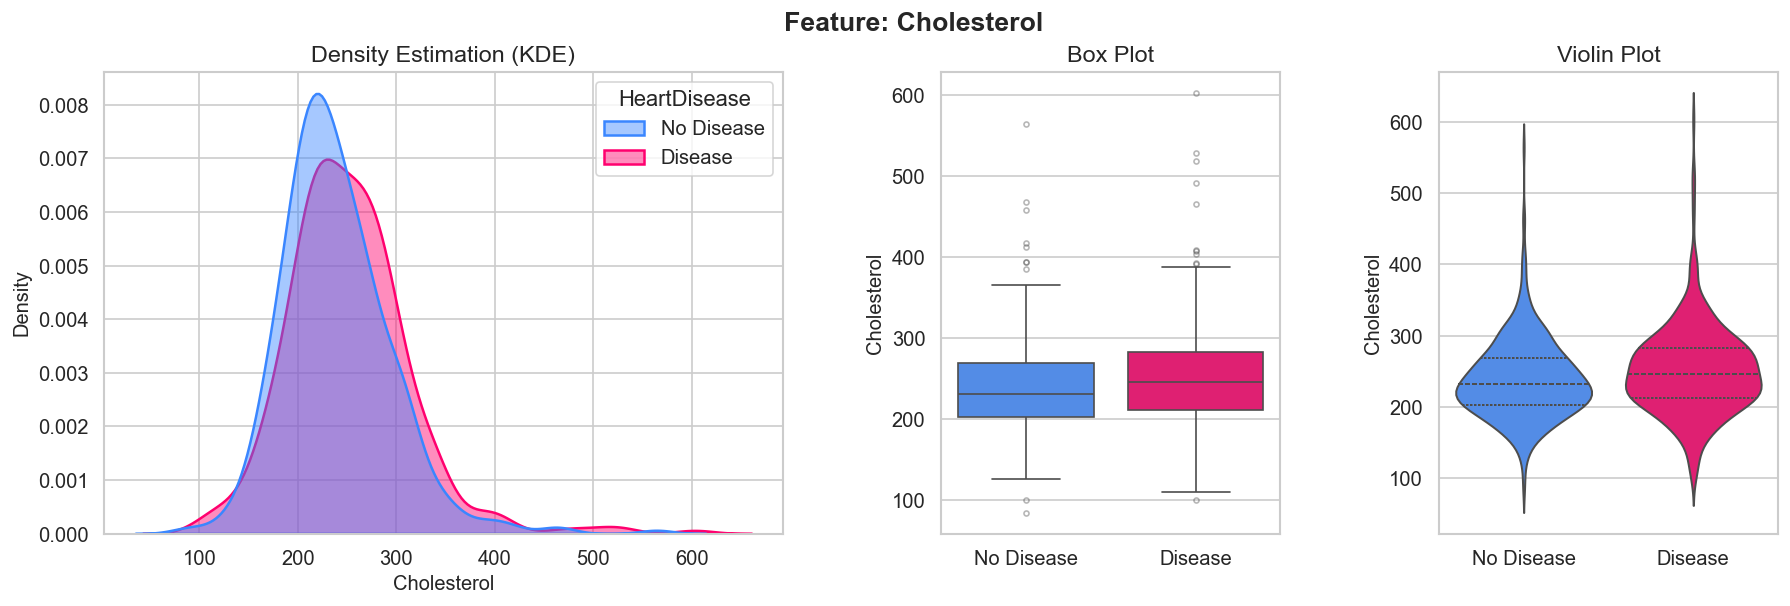

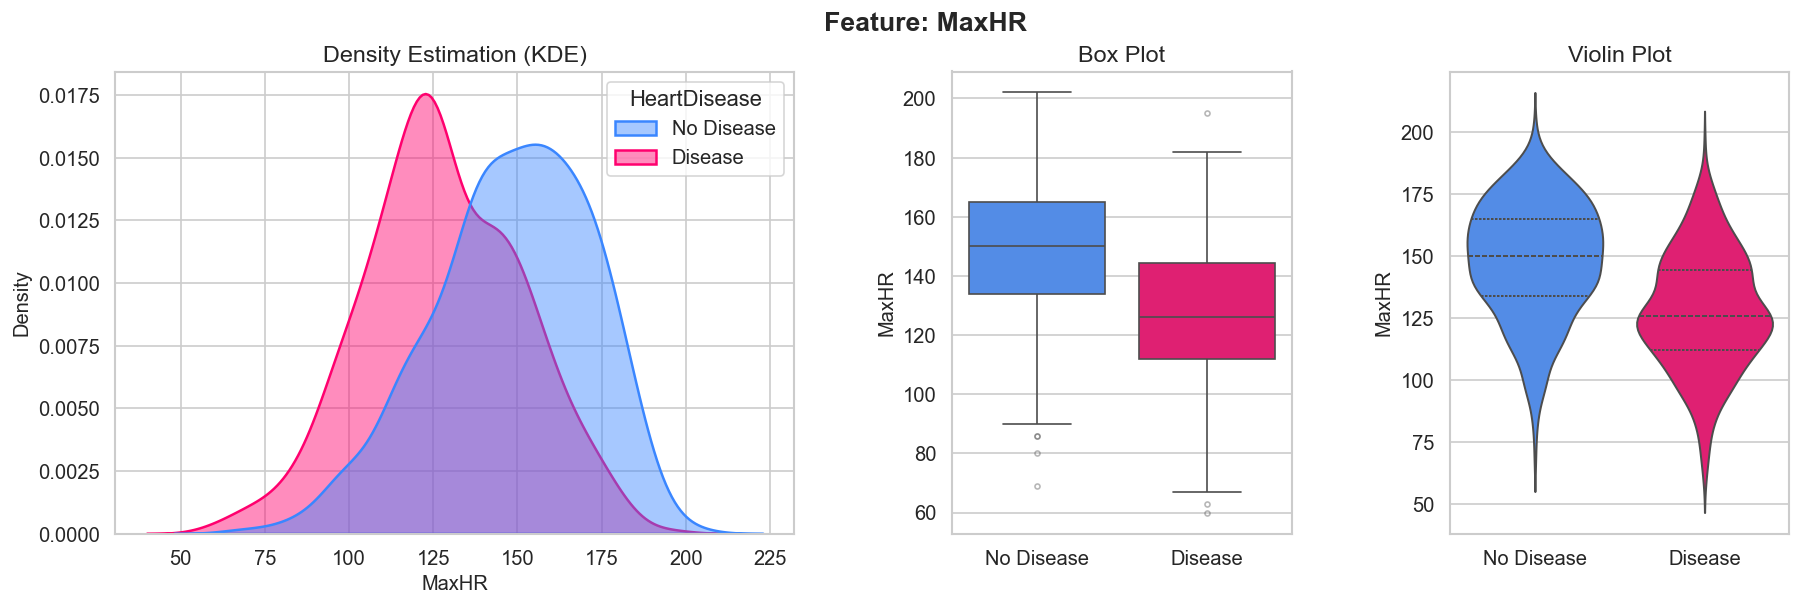

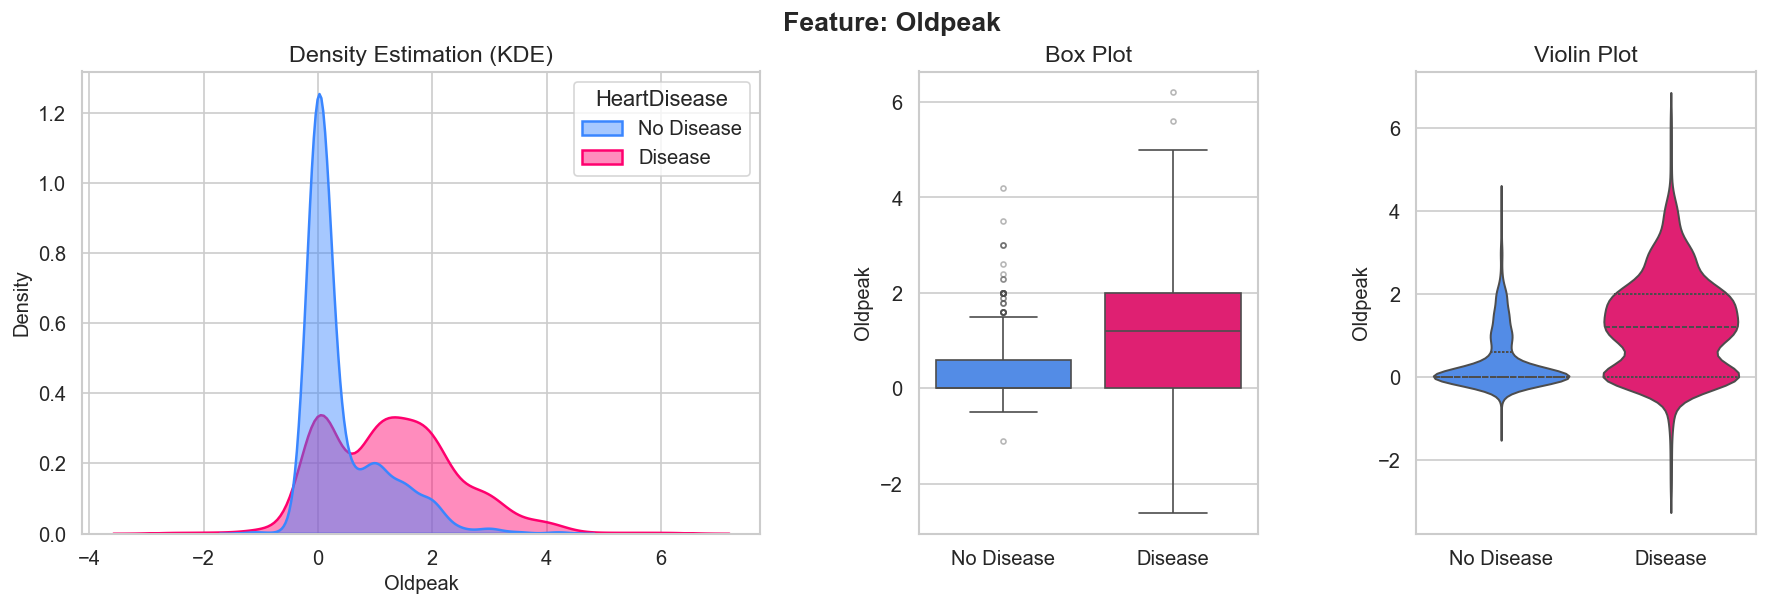

In [56]:
# Numerical features vs. HeartDisease
target_labels = df["HeartDisease"].map({0: "No Disease", 1: "Disease"})
target_labels.name = "HeartDisease"

hue_order = ["No Disease", "Disease"]

for col in numerical_cols:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5),
                                         gridspec_kw={"width_ratios": [2, 1, 1], "wspace": 0.35})

    # KDE
    sns.kdeplot(data=df, x=col, hue=target_labels, fill=True, common_norm=False,
                palette=PALETTE_TARGET, ax=ax1, hue_order=hue_order, alpha=0.45, linewidth=1.5)
    ax1.set_title("Density Estimation (KDE)")
    ax1.set_ylabel("Density")

    # Box plot
    sns.boxplot(data=df, x=target_labels, y=col, palette=PALETTE_TARGET,
                hue=target_labels, legend=False, ax=ax2, order=hue_order,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
    ax2.set_title("Box Plot")
    ax2.set_xlabel("")

    # Violin plot
    sns.violinplot(data=df, x=target_labels, y=col, palette=PALETTE_TARGET,
                   hue=target_labels, legend=False, ax=ax3, order=hue_order,
                   inner="quartile", linewidth=1.2)
    ax3.set_title("Violin Plot")
    ax3.set_xlabel("")

    fig.suptitle(f"Feature: {col}")
    plt.tight_layout()
    plt.show()

### Observations: Numerical Features

| Feature | Key Finding |
|---------|-------------|
| **Age** | The Disease group distribution is shifted right: median age is visibly higher than in the No Disease group. |
| **MaxHR** | Clear separation between groups: the Disease group peaks at a lower MaxHR, indicating that lower maximum heart rate is associated with disease. |
| **Oldpeak** | Strong discriminator — the Disease group has a higher median and wider spread compared to No Disease. |
| **Cholesterol** | After zero-artefact removal, the two groups show only modest separation. Discriminative power to be re-evaluated after imputation. |
| **RestingBP** | The two distributions almost perfectly overlap. Weak discriminator between the two groups. |

<a id='7'></a>
## 7. Correlation Analysis

Categorical variables are one-hot encoded and a Pearson correlation matrix is computed. The analysis has the follow goal:

**Feature → Target:** Identify which features are most correlated with `HeartDisease`.

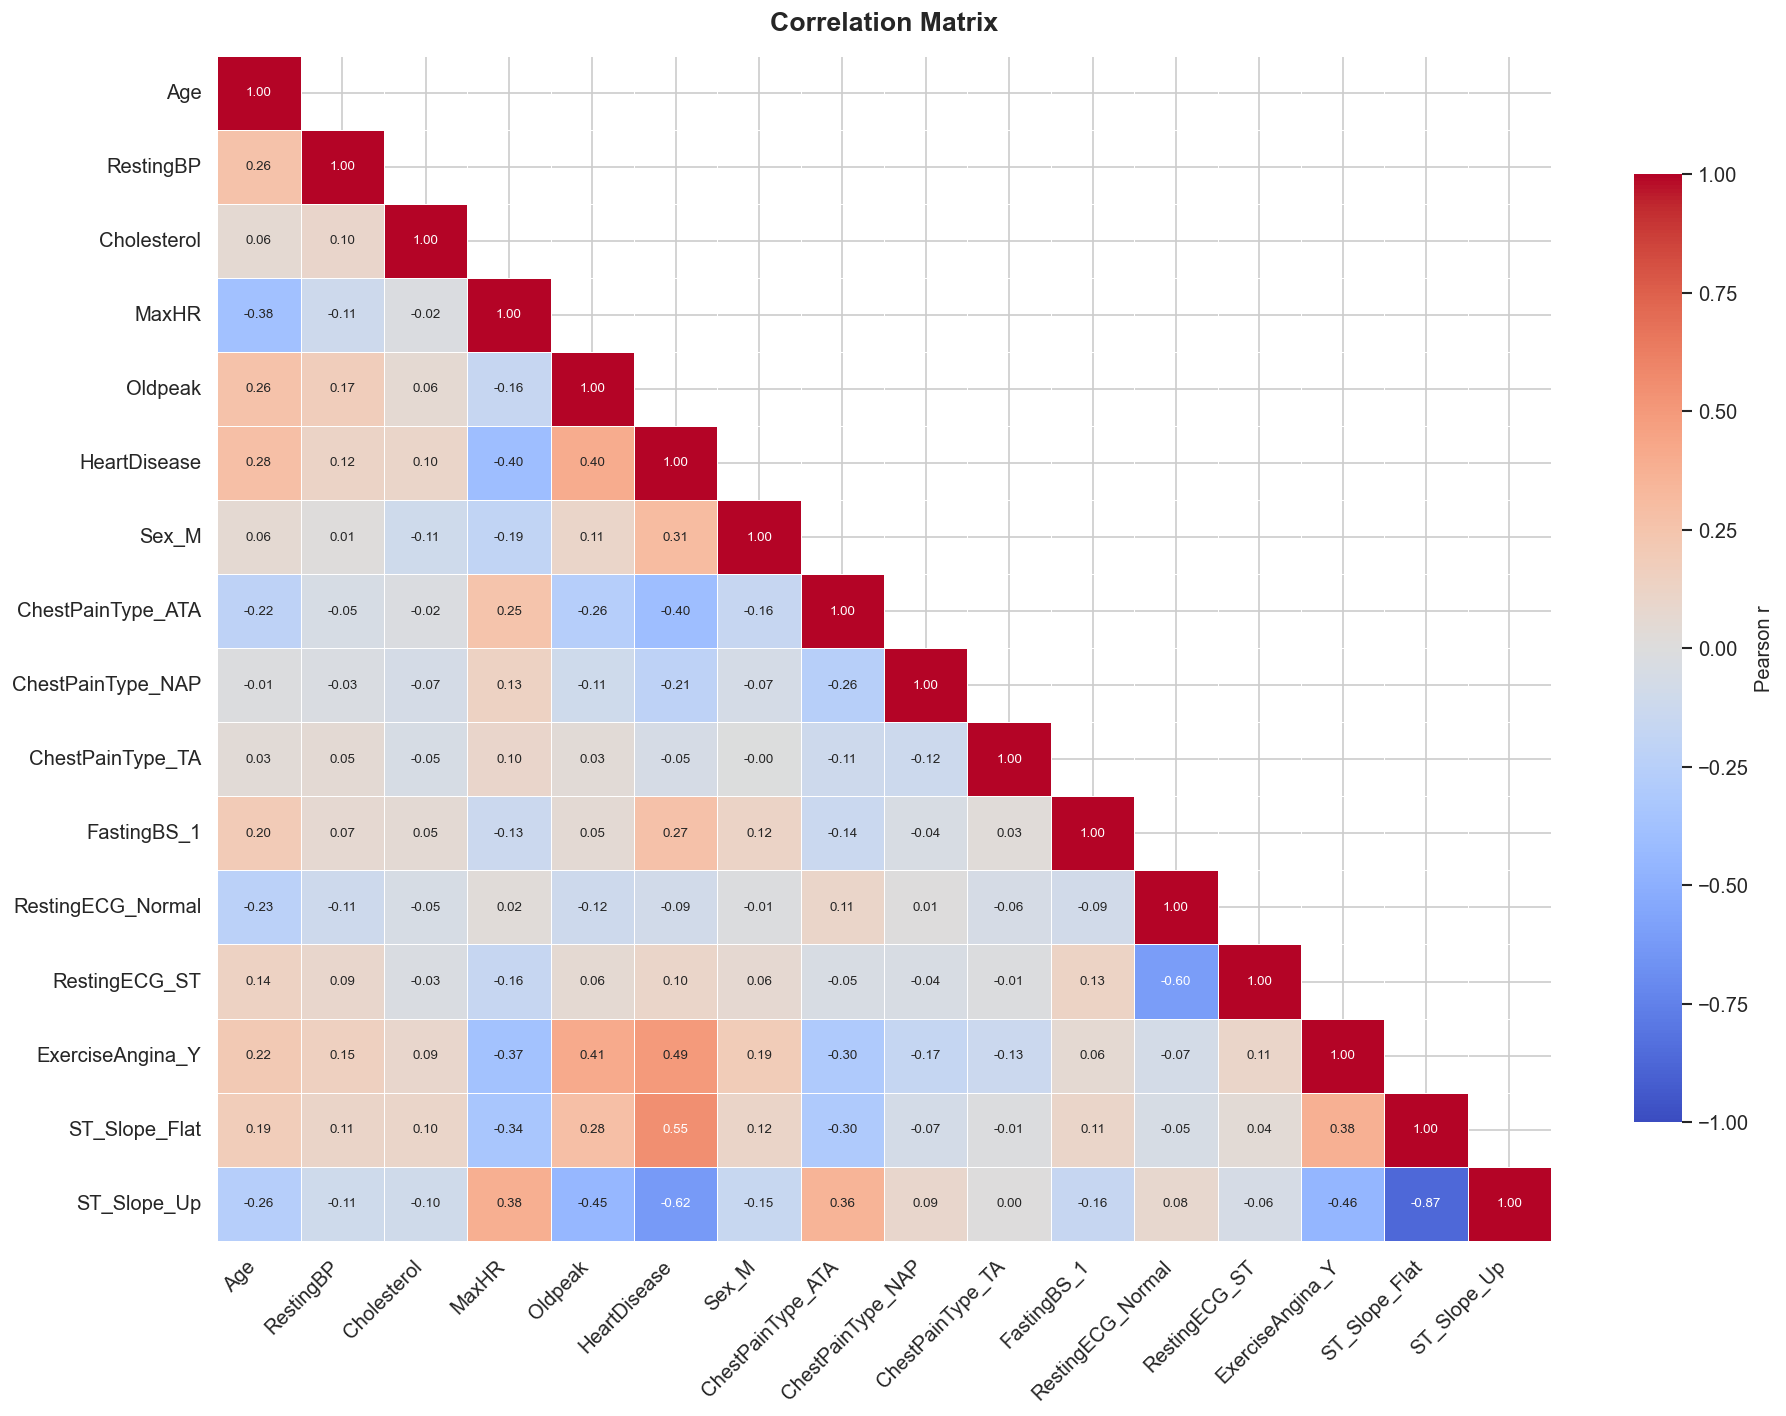

In [59]:
# Correlation matrix (full, one-hot encoded)
df_encoded = pd.get_dummies(df, drop_first=True)
corr_matrix = df_encoded.corr()

# Mask upper triangle for cleaner visualisation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, annot_kws={"size": 8}, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

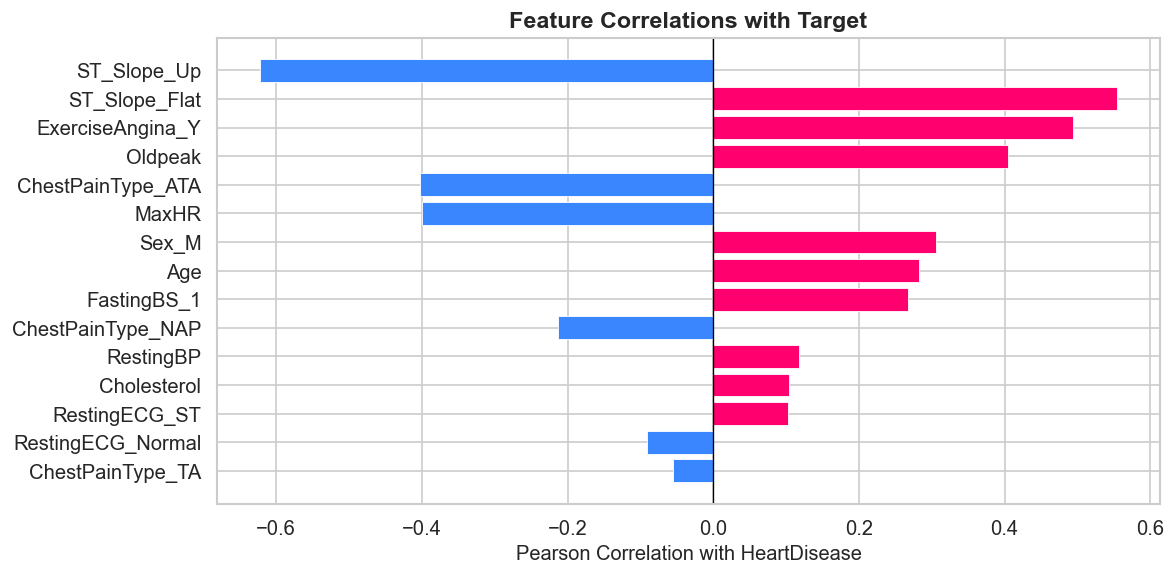

In [60]:
# Top correlations with HeartDisease
target_corr = (
    corr_matrix["HeartDisease"]
    .drop("HeartDisease")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#FF006E" if v > 0 else "#3A86FF" for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1],
        edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with HeartDisease")
ax.set_title("Feature Correlations with Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Correlation Insights

**Feature → Target:**

| Strength | Feature | Correlation | Interpretation |
|----------|---------|-------------|----------------|
| **Strong –** | `ST_Slope_Up` | ≈ −0.62 | Upsloping ST strongly associated with health |
| **Strong +** | `ST_Slope_Flat` | ≈ +0.55 | Flat ST strongly associated with disease |
| **Moderate +** | `ExerciseAngina_Y` | ≈ +0.49 | Exercise-induced angina indicates disease |
| **Moderate +** | `Oldpeak` | ≈ +0.40 | Higher ST depression linked to disease |
| **Moderate –** | `MaxHR` | ≈ −0.40 | Lower max HR linked to disease |
| **Weak +** | `Sex_M` | ≈ +0.31 | Male sex is a risk factor |
| **Weak +** | `FastingBS_1` | ≈ +0.27 | Elevated fasting blood sugar is a risk factor |
| **Weak** | `RestingBP`, `Cholesterol` | < 0.15 | Weak linear predictors individually |

<a id='8'></a>
## 8. Summary & Key Findings

### Data Quality
- **No explicit missing values** were originally present. However, **172 Cholesterol** and **1 RestingBP** values equaled 0, which is physiologically impossible. These were converted to `NaN`.
- The dataset is **reasonably balanced** between the two classes.

### Key Finding

| # | Feature | Key Finding |
|---|---------|-------------|
| 1 | **ST_Slope** | Strongest correlation with the target (Up → healthy, Flat → disease) |
| 2 | **ExerciseAngina** | 85.2% disease risk when positive; strong predictive power |
| 3 | **ChestPainType** | ASY type has 79.0% disease risk; clear class separation |
| 4 | **Oldpeak** | Strong positive correlation (+0.40); clear distribution separation |
| 5 | **MaxHR** | Strong negative correlation (−0.40); lower HR linked to disease |
| 6 | **Sex** | Males at visibly higher risk (63.2% vs 25.9%) |
| 7 | **Age** | Disease group is older on average |

### Weakest Predictors
- **RestingBP**: Nearly overlapping distributions; minimal effect on target.
- **RestingECG**: Similar risk across all categories; very weak correlation.
- **Cholesterol**: Compromised by zero-value artefacts (now cleaned); relationship to be re-evaluated after imputation.